# `uncertain_expansion` — automatic initial guess (v2) and a 25-case robustness grid

The engine in `v2/` is the book's expansion code (the robust steady-state variant), with one change to its entry and two added files:

- `auto_guess.py` — if `uncertain_expansion` is called with `initial_guess=None`, a guess is derived from the model's own equations (a 9-line entry patch; an explicit guess behaves exactly as before).
- `autosolve.py` — a driver that solves from the derived guess, **verifies** the returned steady state against the model's own deterministic equations, and, when a parameter target is not directly solvable, moves one parameter at a time from the model's default values.

No solver mathematics is changed. `v2/PROVENANCE.md` lists every difference from the branch copy, including removed unreachable code.

**Contents**

1. **Model** — five economies, each written out as in the computation appendix: state variable processes, growth process, consumption, constraint; plus the shock-correlation structures.
2. **Solve** — the chapter's economy with no initial guess, then the 25-case grid with consumption-growth elasticities.
3. **Plot** — elasticity term-structure paths for every model (the construction of Figures 11.1–11.3) and the invariance checks.

Runtime: about 15 minutes on Colab.

In [1]:
import os, sys, io, time, warnings, contextlib
warnings.filterwarnings("ignore", category=SyntaxWarning)
try:
    from numba.core.errors import NumbaPerformanceWarning
    warnings.filterwarnings("ignore", category=NumbaPerformanceWarning)
except Exception:
    pass

V2 = "v2"
if not os.path.isdir(V2):
    os.system("git clone -q https://github.com/as7391746/QuantMFR-Colab")
    V2 = "QuantMFR-Colab/v2"
sys.path.insert(0, os.path.abspath(V2))

import numpy as np, sympy as sp
import uncertain_expansion_faisal_feb26 as engine
from autosolve import autosolve
from elasticity import exposure_elasticity, price_elasticity
print("engine:", os.path.relpath(engine.__file__))

engine: v2/uncertain_expansion_faisal_feb26.py


## Model

As in the computation appendix, every economy fits the system

$$
\begin{align}
X_{t+1}(\mathsf{q}) &= \psi^x\left[D_t(\mathsf{q}),\, X_t(\mathsf{q}),\, \mathsf{q}W_{t+1},\, \mathsf{q}\right] \\
\log G_{t+1}(\mathsf{q}) - \log G_t(\mathsf{q}) &= \psi^g\left[D_t(\mathsf{q}),\, X_t(\mathsf{q}),\, \mathsf{q}W_{t+1},\, \mathsf{q}\right] \\
\widehat{C}_t(\mathsf{q}) &= \kappa\left[D_t(\mathsf{q}),\, X_t(\mathsf{q})\right] + \widehat{G}_t(\mathsf{q}) \\
0 &= \phi\left[D_t(\mathsf{q}),\, X_t(\mathsf{q})\right]
\end{align}
$$

with controls $D_t$, states $X_t$, growth variable $G_t = K_t$ (capital), and $W_{t+1} \sim N(0, I)$ i.i.d. Shocks enter through a loading matrix $\Sigma$ whose row $r$ (written $\Sigma_r$) attaches to the growth process ($r=0$) and to each state process; the innovation covariance is $\Sigma\Sigma'$. Terms in $\mathsf{q}^2$ are the Itô corrections of the continuous-time specification, with $\mathsf{q}$ the perturbation parameter.

A model is declared by exactly these pieces: the variable names, $\psi^x$, $\psi^g$, $\kappa$, $\phi$, and a parameter dictionary. `pack` assembles them into the engine's argument list (vector parameters are expanded automatically).

In [2]:
def pack(cv, sv, n_shocks, params, equations):
    shocks = ["W%d_t" % (i + 1) for i in range(n_shocks)]
    variables = cv + sv + ["log_gk_t", "q_t"] + shocks
    vt = [v + "p1" for v in variables]
    flat = {}
    for k, v in params.items():
        a = np.asarray(v, float)
        if a.ndim == 0:
            flat[k] = float(a)
        else:
            for i, x in enumerate(a):
                flat["%s%d" % (k, i + 1)] = float(x)
    pn = {k: sp.Symbol(k) for k in flat}
    g = {n: sp.Symbol(n) for n in list(pn) + variables + vt}
    S = lambda n: g[n]
    kappa, growth, states, constraints = equations(S)
    return {"control_variables": cv, "state_variables": sv, "shock_variables": shocks,
            "variables": variables, "variables_tp1": vt, "kappa": kappa, "growth": growth,
            "state_equations": states, "static_constraints": constraints,
            "parameter_names": pn, "args": list(flat.values()),
            "n_controls": len(cv), "control_names": [c[:-2] for c in cv],
            "state_names": [s[:-2] for s in sv]}

MODELS = {}
BETA = float(np.exp(-0.0025))

### Model 1 — AK with stochastic volatility (the chapter's economy, Section 11.7)

Controls $D_t = (D^1_t, D^2_t)$, the consumption–capital and investment–capital ratios; states $X_t = (Z^1_t, Z^2_t)$, the growth state and the (log) volatility state.

**State variable processes** ($\psi^x$):

$$
\begin{align}
Z^1_{t+1} &= (1 - \nu_1)\,Z^1_t + e^{Z^2_t/2}\,\Sigma_1 \cdot W_{t+1} \\
Z^2_{t+1} &= Z^2_t - \nu_2\left(1 - \mu_2 e^{-Z^2_t}\right) - \frac{\mathsf{q}^2}{2}\,|\Sigma_2|^2 e^{-Z^2_t} + e^{-Z^2_t/2}\,\Sigma_2 \cdot W_{t+1}
\end{align}
$$

**Growth process** ($\psi^g$):

$$\log K_{t+1} - \log K_t = \frac{1}{\zeta}\log\left(1 + \zeta D^2_t\right) + \nu_k Z^1_t - \iota_k - \frac{\mathsf{q}^2}{2}\,|\Sigma_0|^2 e^{Z^2_t} + e^{Z^2_t/2}\,\Sigma_0 \cdot W_{t+1}$$

**Consumption** ($\kappa$):

$$\widehat{C}_t - \widehat{K}_t = \log D^1_t$$

**Constraint** ($\phi$):

$$\alpha - D^1_t - D^2_t = 0$$

`BOOK_SIGMA` below is the chapter's own shock layout, written as the rows of $\Sigma$.

In [3]:
def build_AK(p, L):
    def eqs(S):
        W = [S("W%d_tp1" % (i + 1)) for i in range(L.shape[1])]
        dot = lambda r: sum(float(L[r, i]) * W[i] for i in range(L.shape[1]))
        nn = lambda r: float(L[r] @ L[r])
        kappa = sp.log(S("D1_t"))
        growth = (1 / S("zeta")) * sp.log(1 + S("zeta") * S("D2_t")) + S("nu_k") * S("Z1_t") \
            - S("iota_k") - S("q_t") ** 2 / 2 * nn(0) * sp.exp(S("Z2_t")) + sp.exp(S("Z2_t") / 2) * dot(0)
        Z1n = S("Z1_t") - S("nu_1") * S("Z1_t") + sp.exp(S("Z2_t") / 2) * dot(1)
        Z2n = S("Z2_t") - S("nu_2") * (1 - S("mu_2") * sp.exp(-S("Z2_t"))) \
            - S("q_t") ** 2 / 2 * nn(2) * sp.exp(-S("Z2_t")) + sp.exp(-S("Z2_t") / 2) * dot(2)
        return kappa, growth, [Z1n, Z2n], [S("alpha") - S("D1_t") - S("D2_t")]
    return pack(["D1_t", "D2_t"], ["Z1_t", "Z2_t"], L.shape[1], p, eqs)

BOOK_SIGMA = np.sqrt(3.0) * np.array([[0.92, 0.40, 0.0],
                                      [0.0, 5.70, 0.0],
                                      [0.0, 0.0, 0.00031]])

MODELS["AK"] = dict(build=build_AK, n_states=2, n_shocks=3, norms=[0.012, 0.022, 4.6e-4],
    defaults={"beta": BETA, "rho": 1.001, "gamma": 1.001, "alpha": 0.02305, "zeta": 32.0,
              "iota_k": 0.01, "nu_k": 0.01, "nu_1": 0.014, "nu_2": 0.0485, "mu_2": 6.3e-6},
    target={"gamma": 8.0})

### Model 2 — quadratic installation cost

As Model 1, except the installation technology in the growth process is quadratic.

**Growth process** ($\psi^g$):

$$\log K_{t+1} - \log K_t = D^2_t - \frac{k_q}{2}\left(D^2_t\right)^2 + \nu_k Z^1_t - \iota_k - \frac{\mathsf{q}^2}{2}\,|\Sigma_0|^2 e^{Z^2_t} + e^{Z^2_t/2}\,\Sigma_0 \cdot W_{t+1}$$

State variable processes, consumption, and the constraint are as in Model 1.

In [4]:
def build_QUAD(p, L):
    def eqs(S):
        W = [S("W%d_tp1" % (i + 1)) for i in range(L.shape[1])]
        dot = lambda r: sum(float(L[r, i]) * W[i] for i in range(L.shape[1]))
        nn = lambda r: float(L[r] @ L[r])
        kappa = sp.log(S("D1_t"))
        growth = S("D2_t") - S("kq") / 2 * S("D2_t") ** 2 + S("nu_k") * S("Z1_t") \
            - S("iota_k") - S("q_t") ** 2 / 2 * nn(0) * sp.exp(S("Z2_t")) + sp.exp(S("Z2_t") / 2) * dot(0)
        Z1n = S("Z1_t") - S("nu_1") * S("Z1_t") + sp.exp(S("Z2_t") / 2) * dot(1)
        Z2n = S("Z2_t") - S("nu_2") * (1 - S("mu_2") * sp.exp(-S("Z2_t"))) \
            - S("q_t") ** 2 / 2 * nn(2) * sp.exp(-S("Z2_t")) + sp.exp(-S("Z2_t") / 2) * dot(2)
        return kappa, growth, [Z1n, Z2n], [S("alpha") - S("D1_t") - S("D2_t")]
    return pack(["D1_t", "D2_t"], ["Z1_t", "Z2_t"], L.shape[1], p, eqs)

MODELS["QUAD"] = dict(build=build_QUAD, n_states=2, n_shocks=3, norms=[0.012, 0.022, 4.6e-4],
    defaults={"beta": BETA, "rho": 1.001, "gamma": 1.001, "alpha": 0.02305, "kq": 8.0,
              "iota_k": 0.01, "nu_k": 0.01, "nu_1": 0.014, "nu_2": 0.0485, "mu_2": 6.3e-6},
    target={"gamma": 8.0})

### Model 3 — internal habit

Output is split between consumption $C_t$ (code: `imh_t`) and investment $I_t$ (code: `imk_t`), both relative to capital. A habit stock $X_t$ (log habit per unit of capital) joins the states, $X_t = (Z^1_t, Z^2_t, X_t)$.

**State variable processes** ($\psi^x$): $Z^1$, $Z^2$ as in Model 1, plus the habit stock — a geometric average of its own past and consumption, stated per unit of capital, hence the growth correction:

$$X_{t+1} = \log\left(e^{-\nu_h + X_t} + \left(1 - e^{-\nu_h}\right) C_t\right) - \left(\log K_{t+1} - \log K_t\right)$$

**Growth process** ($\psi^g$): as Model 1 with investment $I_t$ in place of $D^2_t$.

**Consumption** ($\kappa$): a CES aggregate of consumption and habit,

$$\widehat{C}_t - \widehat{K}_t = \frac{1}{1-\tau}\,\log\left((1-\lambda)\,C_t^{\,1-\tau} + \lambda\, e^{(1-\tau) X_t}\right)$$

**Constraint** ($\phi$):

$$\mathsf{a} - C_t - I_t = 0$$

This is the hardest cell of the grid: the solve moves three parameters at once, $\gamma \to 8$, $\lambda \to 0.5$, $\tau \to 0.3$.

In [5]:
def build_HABIT(p, L):
    def eqs(S):
        W = [S("W%d_tp1" % (i + 1)) for i in range(L.shape[1])]
        dot = lambda r: sum(float(L[r, i]) * W[i] for i in range(L.shape[1]))
        nn = lambda r: float(L[r] @ L[r])
        growth = (1 / S("zeta")) * sp.log(1 + S("zeta") * S("imk_t")) + S("nu_k") * S("Z1_t") \
            - S("iota_k") - S("q_t") ** 2 / 2 * nn(0) * sp.exp(S("Z2_t")) + sp.exp(S("Z2_t") / 2) * dot(0)
        Z1n = S("Z1_t") - S("nu_1") * S("Z1_t") + sp.exp(S("Z2_t") / 2) * dot(1)
        Z2n = S("Z2_t") - S("nu_2") * (1 - S("mu_2") * sp.exp(-S("Z2_t"))) \
            - S("q_t") ** 2 / 2 * nn(2) * sp.exp(-S("Z2_t")) + sp.exp(-S("Z2_t") / 2) * dot(2)
        Xn = sp.log(sp.exp(-S("nu_h") + S("X_t")) + (1 - sp.exp(-S("nu_h"))) * S("imh_t")) - growth
        kappa = 1 / (1 - S("tau")) * sp.log((1 - S("llambda")) * S("imh_t") ** (1 - S("tau"))
                                            + S("llambda") * sp.exp((1 - S("tau")) * S("X_t")))
        return kappa, growth, [Z1n, Z2n, Xn], [S("a") - S("imh_t") - S("imk_t")]
    return pack(["imh_t", "imk_t"], ["Z1_t", "Z2_t", "X_t"], L.shape[1], p, eqs)

MODELS["HABIT"] = dict(build=build_HABIT, n_states=3, n_shocks=3, norms=[0.012, 0.022, 4.6e-4],
    defaults={"beta": BETA, "rho": 1.001, "gamma": 1.001, "a": 0.02305, "zeta": 32.0,
              "iota_k": 0.01, "nu_k": 0.01, "nu_1": 0.014, "nu_2": 0.0485, "mu_2": 6.3e-6,
              "nu_h": 0.025, "tau": 1.01, "llambda": -0.0},
    target={"gamma": 8.0, "llambda": 0.5, "tau": 0.3})

### Model 4 — two growth states

States $X_t = (Z^a_t, Z^b_t)$: a fast-reverting growth state ($\nu_a = 0.15$) and a slow, persistent one ($\nu_b = 0.01$).

**State variable processes** ($\psi^x$):

$$Z^a_{t+1} = (1 - \nu_a)\,Z^a_t + \Sigma_1 \cdot W_{t+1}, \qquad Z^b_{t+1} = (1 - \nu_b)\,Z^b_t + \Sigma_2 \cdot W_{t+1}$$

**Growth process** ($\psi^g$): growth responds to the sum of the two states,

$$\log K_{t+1} - \log K_t = \frac{1}{\zeta}\log\left(1 + \zeta D^2_t\right) + \nu_k\left(Z^a_t + Z^b_t\right) - \iota_k + \Sigma_0 \cdot W_{t+1}$$

**Consumption** ($\kappa$): $\;\widehat{C}_t - \widehat{K}_t = \log D^1_t$. **Constraint** ($\phi$): $\;\alpha - D^1_t - D^2_t = 0$.

In [6]:
def build_2STATE(p, L):
    def eqs(S):
        W = [S("W%d_tp1" % (i + 1)) for i in range(L.shape[1])]
        dot = lambda r: sum(float(L[r, i]) * W[i] for i in range(L.shape[1]))
        kappa = sp.log(S("D1_t"))
        growth = (1 / S("zeta")) * sp.log(1 + S("zeta") * S("D2_t")) \
            + S("nu_k") * (S("Za_t") + S("Zb_t")) - S("iota_k") + dot(0)
        Zan = S("Za_t") - S("nua") * S("Za_t") + dot(1)
        Zbn = S("Zb_t") - S("nub") * S("Zb_t") + dot(2)
        return kappa, growth, [Zan, Zbn], [S("alpha") - S("D1_t") - S("D2_t")]
    return pack(["D1_t", "D2_t"], ["Za_t", "Zb_t"], L.shape[1], p, eqs)

MODELS["2STATE"] = dict(build=build_2STATE, n_states=2, n_shocks=3, norms=[0.012, 0.022, 0.008],
    defaults={"beta": BETA, "rho": 1.001, "gamma": 1.001, "alpha": 0.02305, "zeta": 32.0,
              "iota_k": 0.01, "nu_k": 0.01, "nua": 0.15, "nub": 0.01},
    target={"gamma": 8.0})

### Model 5 — stochastic depreciation

One state, $X_t = J_t$, driving depreciation $\iota_k\, e^{J_t}$.

**State variable process** ($\psi^x$):

$$J_{t+1} = (1 - \nu_j)\,J_t + \Sigma_1 \cdot W_{t+1}$$

**Growth process** ($\psi^g$):

$$\log K_{t+1} - \log K_t = \frac{1}{\zeta}\log\left(1 + \zeta D^2_t\right) - \iota_k\, e^{J_t} + \Sigma_0 \cdot W_{t+1}$$

**Consumption** ($\kappa$): $\;\widehat{C}_t - \widehat{K}_t = \log D^1_t$. **Constraint** ($\phi$): $\;\alpha - D^1_t - D^2_t = 0$.

In [7]:
def build_SDEP(p, L):
    def eqs(S):
        W = [S("W%d_tp1" % (i + 1)) for i in range(L.shape[1])]
        dot = lambda r: sum(float(L[r, i]) * W[i] for i in range(L.shape[1]))
        kappa = sp.log(S("D1_t"))
        growth = (1 / S("zeta")) * sp.log(1 + S("zeta") * S("D2_t")) \
            - S("iota_k") * sp.exp(S("J_t")) + dot(0)
        Jn = S("J_t") - S("nuj") * S("J_t") + dot(1)
        return kappa, growth, [Jn], [S("alpha") - S("D1_t") - S("D2_t")]
    return pack(["D1_t", "D2_t"], ["J_t"], L.shape[1], p, eqs)

MODELS["SDEP"] = dict(build=build_SDEP, n_states=1, n_shocks=2, norms=[0.012, 0.05],
    defaults={"beta": BETA, "rho": 1.001, "gamma": 1.001, "alpha": 0.02305, "zeta": 32.0,
              "iota_k": 0.01, "nuj": 0.05},
    target={"gamma": 8.0})

SPECS = ["AK", "QUAD", "HABIT", "2STATE", "SDEP"]

### Shock-correlation structures

Five layouts for $\Sigma$. Row norms are held fixed within each model — only the directions, hence the correlations, differ across families:

| family | description |
|---|---|
| diagonal | one dedicated shock per row (the book's layout) |
| dense | every row loads on every shock |
| leverage | capital and volatility rows nearly opposite (correlation about $-0.9$) |
| collinear | two rows correlated about $0.99$ |
| rankdef | one row an exact linear combination of the others — singular innovation covariance |

In [8]:
def directions(family, n_rows, n_shocks, seed=23):
    rng = np.random.default_rng(seed)
    if family == "diagonal":
        D = np.eye(n_rows, n_shocks)
    elif family == "dense":
        D = rng.standard_normal((n_rows, n_shocks))
    elif family == "leverage":
        D = np.eye(n_rows, n_shocks) + 0.0
        D[0] = np.ones(n_shocks) / np.sqrt(n_shocks)
        D[-1] = -0.9 * D[0] + 0.45 * (np.arange(n_shocks) == n_shocks - 1)
        for i in range(1, n_rows - 1):
            D[i] = rng.standard_normal(n_shocks)
    elif family == "collinear":
        D = rng.standard_normal((n_rows, n_shocks))
        D[1] = D[0] + 0.14 * rng.standard_normal(n_shocks)
    elif family == "rankdef":
        D = rng.standard_normal((n_rows, n_shocks))
        D[-1] = 0.6 * D[0] + (0.4 * D[1] if n_rows > 2 else 0.4 * D[0])
    return D / np.linalg.norm(D, axis=1, keepdims=True)

def loadings(family, norms, n_shocks, rotate=None):
    L = directions(family, len(norms), n_shocks) * np.asarray(norms)[:, None]
    return L @ rotate if rotate is not None else L

FAMILIES = ["diagonal", "dense", "leverage", "collinear", "rankdef"]

## Solve

Two runs.

**First**, the chapter's economy at $\gamma = 8$ with the chapter's own $\Sigma$, calling the engine directly with `initial_guess=None` — the code derives the guess from the equations above.

**Second**, the 25-case grid: every model x every correlation structure, each solved through the driver from the automatically derived guess, plus a rotated twin ($\Sigma \to \Sigma Q$, $Q$ orthogonal) for the invariance check. Every returned steady state is verified against the model's own deterministic equations to $10^{-6}$. For each solution we also compute the consumption-growth exposure and price elasticities for the first shock (median state, 160 quarters) — the same Borovička–Hansen construction as Figures 11.1–11.3.

In [9]:
p_book = dict(MODELS["AK"]["defaults"]); p_book["gamma"] = 8.001
m = build_AK(p_book, BOOK_SIGMA)
t0 = time.time()
with contextlib.redirect_stdout(io.StringIO()):
    sol = engine.uncertain_expansion(m["control_variables"], m["state_variables"],
        m["shock_variables"], m["variables"], m["variables_tp1"], m["kappa"], m["growth"],
        m["state_equations"], m["static_constraints"], None, m["parameter_names"],
        m["args"], approach="1", iter_tol=1e-7, max_iter=500)
ss = np.asarray(sol["ss"], float)
print("solved in %.0f s with no initial guess" % (time.time() - t0))
print("steady-state (D1, D2) = (%.6f, %.6f); closed-form D2 = 0.019023" % (ss[2], ss[3]))

solved in 7 s with no initial guess
steady-state (D1, D2) = (0.004034, 0.019016); closed-form D2 = 0.019023


In [10]:
T_ELAS = 160

def log_sdf(sol, rho_v):
    vmr = sol["vmr1_tp1"] + 0.5 * sol["vmr2_tp1"]
    return (np.log(BETA) - rho_v * sol["gc_tp1"] + (rho_v - 1) * vmr
            + sol["log_N_tilde"])

results, t_grid = [], time.time()
for spec in SPECS:
    M = MODELS[spec]
    tgt = dict(M["defaults"]); tgt.update(M["target"])
    Q, _ = np.linalg.qr(np.random.default_rng(99).standard_normal((M["n_shocks"], M["n_shocks"])))
    for fam in FAMILIES:
        L0 = loadings(fam, M["norms"], M["n_shocks"])
        L1 = loadings(fam, M["norms"], M["n_shocks"], rotate=Q)
        cell = {"spec": spec, "family": fam}
        t1 = time.time()
        r, msg = autosolve(lambda p, L=L0: M["build"](p, L), M["defaults"], tgt,
                           M["n_states"], M["n_shocks"])
        cell["solved"] = r is not None
        if r is not None:
            cell["ss"] = np.asarray(r["ss"], float)
            cell["expo"] = exposure_elasticity(r["gc_tp1"], r["X1_tp1"], r["X2_tp1"],
                                               T_ELAS, shock=0, percentile=0.5).flatten()
            cell["price"] = price_elasticity(r["gc_tp1"], log_sdf(r, tgt["rho"]),
                                             r["X1_tp1"], r["X2_tp1"],
                                             T_ELAS, shock=0, percentile=0.5).flatten()
            r2, _ = autosolve(lambda p, L=L1: M["build"](p, L), M["defaults"], tgt,
                              M["n_states"], M["n_shocks"])
            cell["ss_rot"] = np.asarray(r2["ss"], float) if r2 is not None else None
        else:
            cell["note"] = msg
        cell["secs"] = round(time.time() - t1)
        results.append(cell)
        print("  %-7s x %-9s: %s %3ds" % (spec, fam,
              "OK  " if cell["solved"] else "FAIL", cell["secs"]), flush=True)
print("grid finished in %.1f min" % ((time.time() - t_grid) / 60))

  AK      x diagonal : OK     7s


  AK      x dense    : OK     4s


  AK      x leverage : OK     4s


  AK      x collinear: OK     4s


  AK      x rankdef  : OK     4s


...

  SDEP    x dense    : OK     2s


  SDEP    x leverage : OK     2s


  SDEP    x collinear: OK     2s


  SDEP    x rankdef  : OK     2s


grid finished in 2.5 min


## Plot

Everything below only reads `results`.

**Elasticity paths.** For every model, the term structures of the consumption-growth **exposure** elasticity (how much a unit of date-1 exposure to the first shock moves expected consumption at each horizon) and the **price** elasticity (the expected-return compensation per unit of that exposure) — the construction of Figures 11.1–11.3. What to check: every path is smooth and settles, none explodes or oscillates; and the five correlation structures fan the paths out, since correlations act on orders 1 and 2.

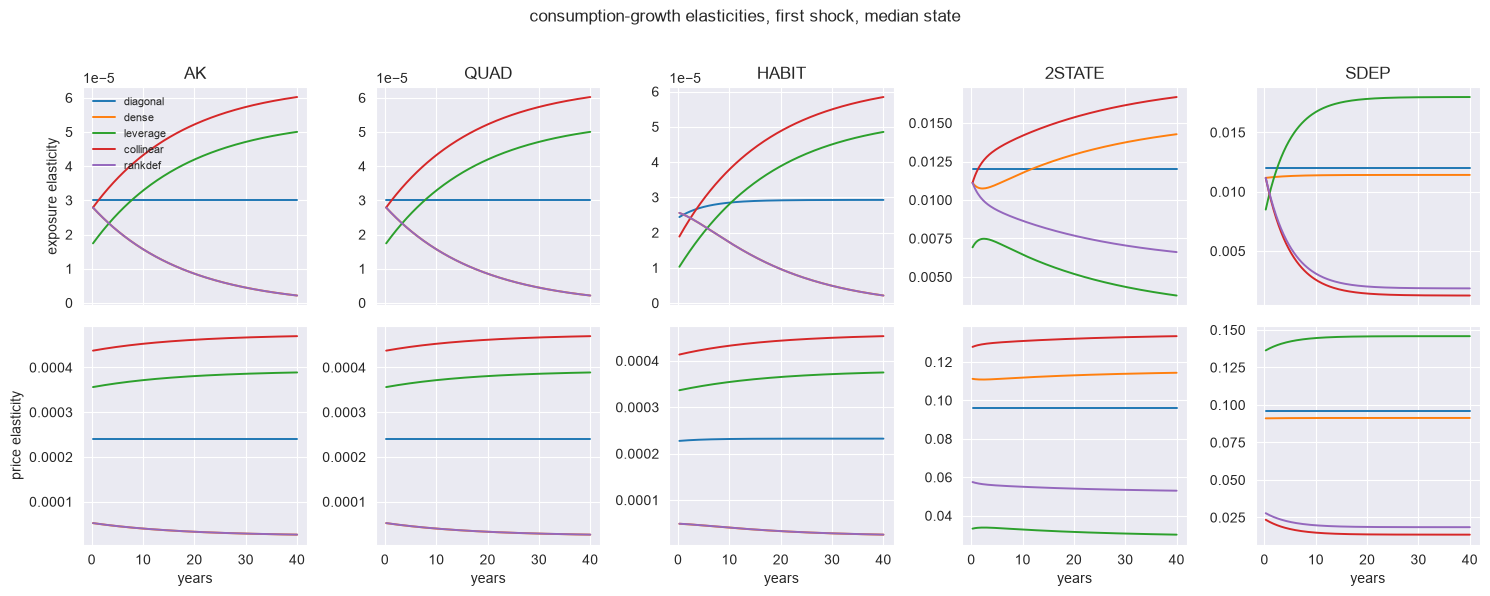

In [11]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
df = pd.DataFrame(results)
sns.set_style("darkgrid")
yrs = np.arange(1, T_ELAS + 1) / 4
fig, axes = plt.subplots(2, len(SPECS), figsize=(15, 5.8), sharex=True)
for j, spec in enumerate(SPECS):
    for fam in FAMILIES:
        c = df[(df.spec == spec) & (df.family == fam)].iloc[0]
        if not c.solved:
            continue
        axes[0, j].plot(yrs, c.expo, label=fam, lw=1.4)
        axes[1, j].plot(yrs, c.price, lw=1.4)
    axes[0, j].set_title(spec)
    axes[1, j].set_xlabel("years")
axes[0, 0].set_ylabel("exposure elasticity")
axes[1, 0].set_ylabel("price elasticity")
axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle("consumption-growth elasticities, first shock, median state", y=1.02)
fig.tight_layout(); plt.show()

**Invariance checks.** Order 0: within each model the steady state must be *identical* across the five correlation structures — $\Sigma$ enters the deterministic system only through $\mathsf{q}^2$ terms, which vanish at order 0 — and unchanged under $\Sigma \to \Sigma Q$.

In [12]:
def spread(g):
    ref = g.iloc[0]
    return max(float(np.max(np.abs(s - ref))) for s in g.iloc[1:]) if len(g) > 1 else 0.0

summary = pd.DataFrame({
    "solved": ["%d / %d" % (df[df.spec == s].solved.sum(), len(FAMILIES)) for s in SPECS],
    "order-0 spread across families": [spread(df[df.spec == s].dropna(subset=["ss"]).ss) for s in SPECS],
    "max rotation diff": [max(float(np.max(np.abs(c.ss - c.ss_rot))) for _, c in df[df.spec == s].iterrows()
                              if c.ss_rot is not None) for s in SPECS],
}, index=SPECS)
display(summary)

,solved,order-0 spread across families,max rotation diff
AK,5 / 5,0.0,0.0
QUAD,5 / 5,0.0,0.0
HABIT,5 / 5,0.0,0.0
2STATE,5 / 5,0.0,0.0
SDEP,5 / 5,0.0,0.0


**Reading the results.**

- Every one of the 25 cases solves from the automatically derived guess, and every elasticity path is smooth and settles at long horizons — no divergence or oscillation in any model under any correlation structure.
- **Order 0 is untouched by correlations**: within every model the steady state is identical, digit for digit, across the five structures and under rotations of $\Sigma$ (both columns of the table are exactly zero).
- **Orders 1 and 2 respond to correlations**: within each model the five structures fan the elasticity paths out — the correlations show up exactly where the theory puts them, and nowhere else.
- Every steady state above was verified against the model's own equations; nothing relies on the solver's internal convergence report.